# Sleep method

## .NET Thread.Sleep Method

Documentation: https://learn.microsoft.com/en-us/dotnet/api/system.threading.thread.sleep?view=net-10.0

The selected method allows to specify sleep time in milliseconds. To get the current time we will use Stopwatch.GetTimestamp method discussed in the previous task which has 100 ns of resolution and granularity.

The script is available in the `c-sharp-sleep\Program.cs` file.

The command to build the .NET project: `dotnet build` inside the project directory

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

def read_sleep_results(path):
    return pd.read_csv(path, header=None, names=['timestamp'], sep=';', decimal=',')

path = './result-data/sleep-results-1ms.csv'
path_warmup = './result-data/sleep-results-warmup-1ms.csv'

df = read_sleep_results(path)
df_warmup = read_sleep_results(path_warmup)

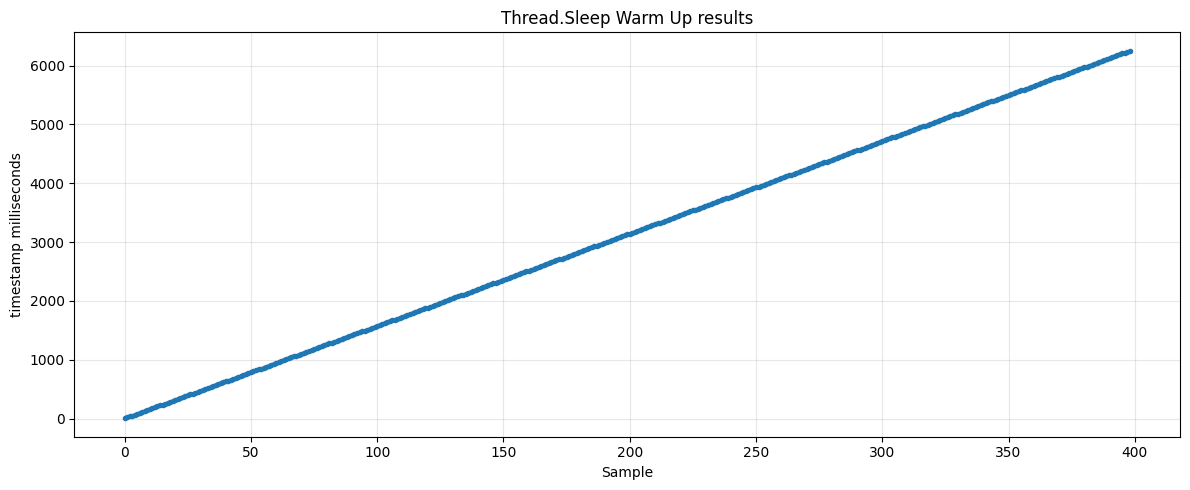

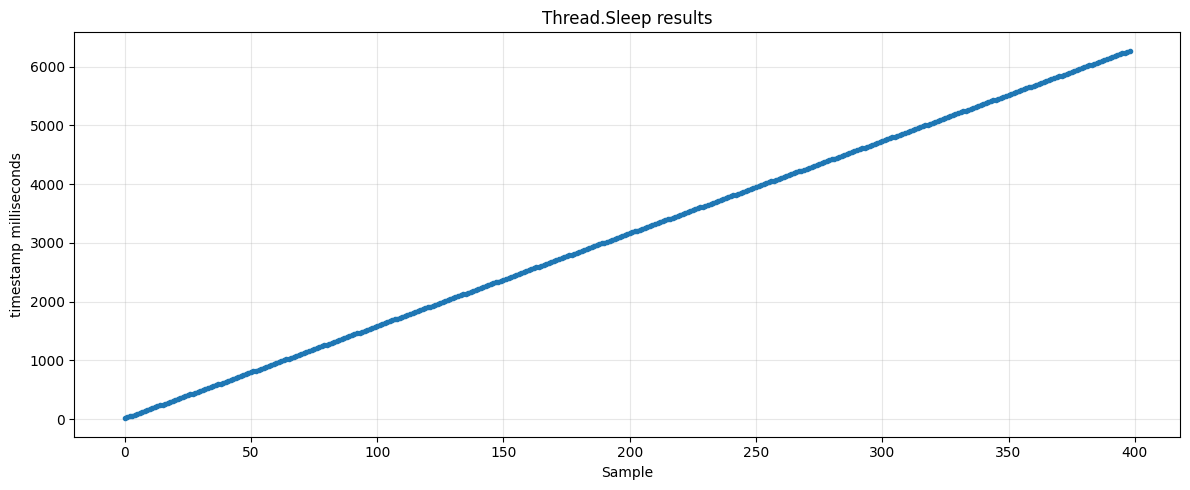

In [2]:
def plot_timer_results(df, title):
    plt.figure(figsize=(12, 5))
    plt.plot(df.index, df["timestamp"], marker=".", linestyle="-")
    plt.xlabel("Sample")
    plt.ylabel("timestamp milliseconds")
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
plot_timer_results(df_warmup, "Thread.Sleep Warm Up results")
plot_timer_results(df, "Thread.Sleep results")

### The overhead of the sleep (related to minimum duration)
We can calculate the average overhead:

In [3]:
def calculate_access_overhead(df):
    values = df["timestamp"]
    adjacent_differences = values.diff().dropna()
    sum_of_adjacent_differences = adjacent_differences.sum()
    average_value = sum_of_adjacent_differences / len(adjacent_differences)

    print(f"Number of adjacent differences: {len(adjacent_differences)}")
    print(f"Sum of adjacent differences: {sum_of_adjacent_differences}")
    print(f"Average of access overhead: {average_value} ms")

calculate_access_overhead(df)

Number of adjacent differences: 398
Sum of adjacent differences: 6254.9947
Average of access overhead: 15.716067085427136 ms


So, for sleeping 1 ms the overhead almost 16 times larger that the desired delay.

### The granularity of the sleep (related to minimum increment)

In [4]:
def calculate_minimum_increment(df):
    values = df["timestamp"]
    adjacent_differences = values.diff().dropna()
    adjacent_differences = adjacent_differences[adjacent_differences > 0]
    min_of_adjacent_differences = adjacent_differences.min()

    print(f"Minimum of adjacent differences: {min_of_adjacent_differences}")

calculate_minimum_increment(df)

Minimum of adjacent differences: 14.513799999999947


As for the minimum increment it is almost as large as the average value. So the granularity is around 14.51 ms